REMIND!!! database can't be shared. To get database.csv ask master :)

In [53]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
from collections import Counter
import re

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)



На моей любимой площадке, где я делаю заказы на игры раньше отображалось сколько за услугу заплатил заказчик, но теперь они скрыли эту информацию, но я как инфобезник решил не взламывать их базу данных, а пойти более легальным путём и наобучать модель, чтобы она мне рассказала правду :)

Признак  | Описание
-------------------|--------------------
CHANNEL       | Название откуда взят заказ
ORDER_DESC       | Название заказа
SERVICE       | Номер заказа
ORDER_PRICE       | Цена заказа для работника
REAL_PRICE | Сколько заплатил за неё заказчик
TIMESTAMP | Время выдачи заказа на панель

In [54]:
database = pd.read_csv('database.csv')
database

,CHANNEL,ORDER_DESC,ORDER_INFO,SERVICE,ORDER_PRICE,REAL_PRICE,TIMESTAMP
0,PS4,Briarbinds Exotic Gauntlets - Warlock + I want...,\nProgress: Let's get this exotic!,LFCarry 5264C4,21.00,NaN,2023-08-27 22:26:55.842860
1,XBOX,Sanctified Mind Kill - Garden of Salvation Fin...,\nProgress: My charchter Is 1710 have some goo...,LFCarry 26174B,1.00,NaN,2023-08-27 22:31:06.123748
2,PS4,Ghosts of the Deep Dungeon,\nplatform: PlayStation\nDifficulty: Solo\nadd...,SkyCoach IT77820,5.94,32.29,2023-08-27 22:34:45.369146
3,PS4,Last Wish Raid,\nplatform: PlayStation\nDifficulty: Full Raid...,SkyCoach UU77818,2.68,13.58,2023-08-27 22:34:46.987360
4,PS4,↑↑Ghosts of the Deep Dungeon,\nplatform: PlayStation\nDifficulty: Solo\nadd...,SkyCoach IT77820,8.91,32.29,2023-08-27 22:37:14.760444
...,...,...,...,...,...,...,...
12499,PC,Root of Nightmares Seal (Dream Warrior),\nplatform: PC\nAll Hands : True\nDifficulty: ...,SkyCoach NC71221,3.27,14.74,2023-11-23 21:09:22.663019
12500,PC,↑↑Master Root of Nightmares,\nplatform: PC\nDifficulty: Full Clear\nDay On...,SkyCoach AM71186,28.09,67.07,2023-11-23 21:10:12.787012
12501,PC,↑↑Weekly Rotation Conditional Finality,\nplatform: PC\nAmount of Runs: ['Amount of Ru...,SkyCoach EH71218,6.00,21.01,2023-11-23 21:15:19.644123
12502,XBOX,↑↑Crota's End Seal (Swordbearer Title),\nplatform: XBOX\nDifficulty: Specific Triumph...,SkyCoach PY71197,3.08,7.28,2023-11-23 21:19:15.519790


Заметим, что некоторые данные повторяются, так как записи получались поочередно, пока не получится максимальный прайс. Удалим дубликаты, а также колонку SERVICE т.к. она не повлияет на ценообразование

In [55]:
database.sort_values(by=['SERVICE', 'ORDER_PRICE'], ascending=[True, False], inplace=True)
database.drop_duplicates(subset='SERVICE', keep='first', inplace=True)
database.drop(columns=['SERVICE', 'CHANNEL'], inplace=True)

Попробуем преобразовать строковое значение времени в число, чтобы также получать зависимость от времени, когда вышел заказ

In [56]:
database['TIMESTAMP'] = pd.to_datetime(database['TIMESTAMP'])
database['MINUTES'] = database['TIMESTAMP'].dt.hour * 60 + database['TIMESTAMP'].dt.minute
database.drop(columns=['TIMESTAMP'], inplace=True)

Заметим, что некоторые заказы не имеют реальной цены, так что получим усредненный коэф. преобразования и применим его к пропущенным значениям

In [57]:
database['REAL_PRICE'] = pd.to_numeric(database['REAL_PRICE'], errors='coerce')
database['ORDER_PRICE'] = pd.to_numeric(database['ORDER_PRICE'])
database['COEF'] = database['REAL_PRICE']/database['ORDER_PRICE']
coef = database['COEF'].mean()
database['REAL_PRICE'] = database.apply(lambda row: row['ORDER_PRICE']*coef if pd.isnull(row['REAL_PRICE']) else row['REAL_PRICE'], axis=1)
database['COEF'] = database.apply(lambda row: coef if pd.isnull(row['COEF']) else row['COEF'], axis=1)

Преобразуем описания и информацию по заказам.
↑↑ -> значит, что заказ был повышен в цене 

In [58]:
database['ORDER_DESC'] = database['ORDER_DESC'].str.replace('↑↑', ' ')
database['ORDER_DESC'] = database['ORDER_DESC'].str.replace('\n', ' ')
database['ORDER_INFO'] = database['ORDER_INFO'].str.replace('\n', ' ')

Получим 150 самых использованных слов, посмотрим сколько раз они встречаются и как коррелируют с COEF, т.к. он решает каким будет REAL_PRICE от ORDER_PRICE

In [59]:
words = ''.join(database['ORDER_DESC'].astype(str)) + ' '.join(database['ORDER_INFO'].astype(str))
count = Counter(words.split(' ')).most_common(150)
for word in count:
    pattern = re.escape(word[0])
    counts = database['ORDER_DESC'].str.count(pattern) + database['ORDER_INFO'].str.count(pattern)
    database[word[0]] = counts

database = database.drop(columns=['ORDER_DESC', 'ORDER_INFO'])

In [60]:
corr_matrix = database.corr()
real_price_corr = corr_matrix['COEF'].drop(labels=['COEF', 'REAL_PRICE', 'ORDER_PRICE'])
least_corr_predictors = real_price_corr.nsmallest(130).index
database = database.drop(columns=least_corr_predictors)

Посмотрим на распределения чисел в целом

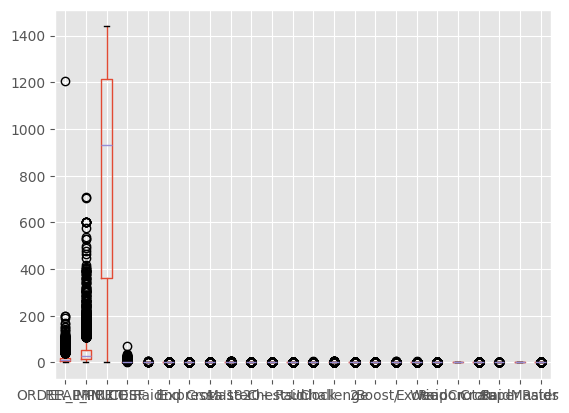

In [61]:
database.boxplot()
plt.show()

Попробуем стандартизировать 

In [62]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
standard_database = pd.DataFrame(data = standard_scaler.fit_transform(database), index = database.index, columns = database.columns)

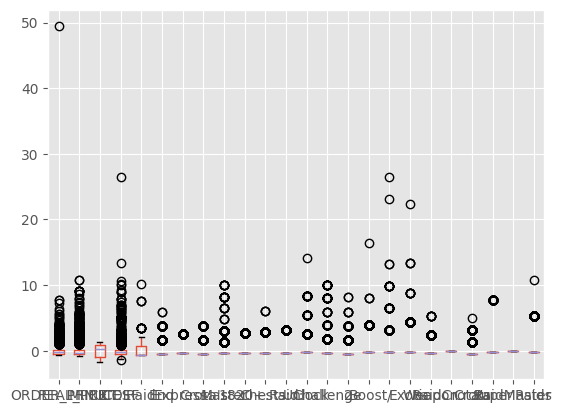

In [63]:
standard_database.boxplot()
plt.show()

In [64]:
final_database = standard_database

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X = final_database.drop(columns=['REAL_PRICE'])
y = final_database['REAL_PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Посмотрим на всякие интересные метрики

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mead = pd.Series(abs(y_test - y_pred)).median()

print(mse, mae, r2, mead)

0.050292241595611 0.04803837157986217 0.9574389117739008 0.00706464182157196


Получаем вполне не плохой результат :)